# 05 — Train GaitTR

First run tiny overfit. Then set `RUN_FULL_TRAINING=True`.

In [1]:
from pathlib import Path
import os, random, time, gc, math
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

EXP_DIR = Path('/media/wadud/DriveUbuntu/GaitRecognition 2.0')
POSE_TAG = None  # None = auto-detect folder under data/poses with most .npz files
POSES_DIR = EXP_DIR / 'data' / 'poses'
SPLIT_DIR = EXP_DIR / 'data' / 'splits'
REPORT_DIR = EXP_DIR / 'data' / 'reports'
RESULT_DIR = EXP_DIR / 'results'
CHECKPOINT_DIR = EXP_DIR / 'checkpoints'
LOG_DIR = EXP_DIR / 'logs'
for d in [SPLIT_DIR, REPORT_DIR, RESULT_DIR, CHECKPOINT_DIR, LOG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

def detect_pose_root(poses_dir=POSES_DIR, pose_tag=POSE_TAG):
    if pose_tag is not None:
        root = poses_dir / pose_tag
        if not root.exists():
            raise FileNotFoundError(root)
        return root
    candidates = [p for p in poses_dir.iterdir() if p.is_dir()] if poses_dir.exists() else []
    if not candidates:
        raise FileNotFoundError(f'No pose folders under {poses_dir}')
    counts = sorted([(len(list(p.rglob('*.npz'))), p) for p in candidates], reverse=True, key=lambda x: x[0])
    return counts[0][1]

POSE_ROOT = detect_pose_root()
print('EXP_DIR  :', EXP_DIR)
print('POSE_ROOT:', POSE_ROOT)

SPLIT_NAME='LT'; SEQ_LEN=60; P=8; K=4; STEPS_PER_EPOCH=1000; MAX_STEPS=30000
NUM_WORKERS=2; USE_AMP=True; LR_MAX=1e-3; WEIGHT_DECAY=2e-5; MARGIN=0.3
EMBEDDING_DIM=128; CHANNELS=(64,64,128,256); NUM_HEADS=8; TEMPORAL_KERNEL=9; DROPOUT=0.1
RUN_TINY_OVERFIT_TEST=True; RUN_FULL_TRAINING=False; TINY_SUBJECTS=5; TINY_STEPS=500; SAVE_EVERY=1000; LOG_EVERY=50
TRAIN_CSV=SPLIT_DIR/f'train_{SPLIT_NAME}.csv'; assert TRAIN_CSV.exists(), TRAIN_CSV
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu'); print('device:',device); print('train csv:',TRAIN_CSV)

EXP_DIR  : /media/wadud/DriveUbuntu/GaitRecognition 2.0
POSE_ROOT: /media/wadud/DriveUbuntu/GaitRecognition 2.0/data/poses/yolo26l_pose
device: cuda
train csv: /media/wadud/DriveUbuntu/GaitRecognition 2.0/data/splits/train_LT.csv


In [2]:
COCO_PARENTS = np.array([0,0,0,1,2,0,0,5,6,7,8,5,6,11,12,13,14], dtype=np.int64)
LEFT_RIGHT_PAIRS = [(1,2),(3,4),(5,6),(7,8),(9,10),(11,12),(13,14),(15,16)]

def crop_or_pad_sequence(X, seq_len=60, random_crop=True):
    T = X.shape[0]
    if T == seq_len:
        return X
    if T > seq_len:
        start = np.random.randint(0, T-seq_len+1) if random_crop else max(0, (T-seq_len)//2)
        return X[start:start+seq_len]
    pad = np.repeat(X[-1:], seq_len-T, axis=0)
    return np.concatenate([X, pad], axis=0)

def swap_left_right(X):
    X = X.copy()
    for l, r in LEFT_RIGHT_PAIRS:
        X[:, [l, r], :] = X[:, [r, l], :]
    return X

def augment_skeleton(X):
    if np.random.rand() < 0.5:
        X = swap_left_right(X)
    X = X + np.random.normal(0, 0.005, size=X.shape).astype(np.float32)
    X = X + np.random.normal(0, 0.01, size=(1,1,2)).astype(np.float32)
    return X

def build_gaittr_features(X):
    X = X.astype(np.float32)
    assert X.ndim == 3 and X.shape[1:] == (17,2), f'Bad skeleton shape: {X.shape}'
    joint = X.copy()
    joint_rel = X - X[:, 0:1, :]
    v1 = np.zeros_like(X); v1[:-1] = X[1:] - X[:-1]
    v2 = np.zeros_like(X); v2[:-2] = X[2:] - X[:-2]
    bone = X - X[:, COCO_PARENTS, :]
    feat = np.concatenate([joint, joint_rel, v1, v2, bone], axis=-1)
    return feat.transpose(2,0,1).astype(np.float32)  # 10,T,17

In [3]:
from torch.utils.data import Dataset, DataLoader, Sampler

class CASIABGaitTRDataset(Dataset):
    def __init__(self, df, label_map, seq_len=60, train=True):
        self.df = df.reset_index(drop=True)
        self.label_map = label_map
        self.seq_len = seq_len
        self.train = train
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        data = np.load(row['pose_path'])
        X = data['keypoints_norm_filled'].astype(np.float32)
        X = crop_or_pad_sequence(X, self.seq_len, random_crop=self.train)
        if self.train:
            X = augment_skeleton(X)
        feat = build_gaittr_features(X)
        return {
            'x': torch.from_numpy(feat),
            'label': torch.tensor(self.label_map[str(row['subject'])], dtype=torch.long),
            'subject': str(row['subject']),
            'condition': str(row['condition']),
            'seq': str(row['seq']),
            'view': str(row['view']),
            'pose_path': str(row['pose_path'])
        }

class PKBatchSampler(Sampler):
    def __init__(self, labels, p=8, k=4, steps_per_epoch=1000):
        self.labels = np.asarray(labels); self.p=p; self.k=k; self.steps_per_epoch=steps_per_epoch
        self.label_to_indices = {}
        for idx, lab in enumerate(self.labels):
            self.label_to_indices.setdefault(int(lab), []).append(idx)
        self.unique_labels = list(self.label_to_indices.keys())
        if len(self.unique_labels) < p:
            raise ValueError(f'Need at least p={p} identities, got {len(self.unique_labels)}')
    def __iter__(self):
        for _ in range(self.steps_per_epoch):
            selected = random.sample(self.unique_labels, self.p)
            batch=[]
            for lab in selected:
                idxs = self.label_to_indices[lab]
                batch.extend(random.sample(idxs, self.k) if len(idxs) >= self.k else random.choices(idxs, k=self.k))
            yield batch
    def __len__(self): return self.steps_per_epoch

In [4]:
class TCN(nn.Module):
    def __init__(self, in_channels, out_channels, temporal_kernel=9, dropout=0.1):
        super().__init__(); pad = temporal_kernel // 2
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=(temporal_kernel,1), padding=(pad,0), bias=False),
            nn.Dropout(dropout), nn.Mish(), nn.BatchNorm2d(out_channels)
        )
    def forward(self, x): return self.net(x)

class SpatialTransformer(nn.Module):
    def __init__(self, channels, num_heads=8, dropout=0.1):
        super().__init__(); assert channels % num_heads == 0
        self.norm = nn.LayerNorm(channels)
        self.attn = nn.MultiheadAttention(channels, num_heads, dropout=dropout, batch_first=True)
        self.proj = nn.Linear(channels, channels)
        self.act = nn.Mish(); self.bn = nn.BatchNorm2d(channels)
    def forward(self, x):
        B,C,T,V = x.shape
        tok = x.permute(0,2,3,1).contiguous().view(B*T, V, C)
        tok = self.norm(tok)
        out, _ = self.attn(tok, tok, tok, need_weights=False)
        out = self.proj(out).view(B,T,V,C).permute(0,3,1,2).contiguous()
        return self.bn(self.act(out))

class TCNSTBlock(nn.Module):
    def __init__(self, in_channels, out_channels, num_heads=8, temporal_kernel=9, dropout=0.1):
        super().__init__()
        self.tcn = TCN(in_channels, out_channels, temporal_kernel, dropout)
        self.st = SpatialTransformer(out_channels, num_heads, dropout)
        self.res = nn.Identity() if in_channels == out_channels else nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False), nn.Mish(), nn.BatchNorm2d(out_channels)
        )
    def forward(self, x): return self.st(self.tcn(x)) + self.res(x)

class GaitTR(nn.Module):
    def __init__(self, in_channels=10, embedding_dim=128, channels=(64,64,128,256), num_heads=8, temporal_kernel=9, dropout=0.1):
        super().__init__(); self.data_bn = nn.BatchNorm2d(in_channels)
        blocks=[]; prev=in_channels
        for ch in channels:
            blocks.append(TCNSTBlock(prev, ch, num_heads, temporal_kernel, dropout)); prev=ch
        self.blocks = nn.Sequential(*blocks); self.fc = nn.Linear(channels[-1], embedding_dim, bias=False)
    def forward(self, x):
        x = self.data_bn(x); x = self.blocks(x); x = x.mean(dim=(2,3))
        return F.normalize(self.fc(x), p=2, dim=1)

class BatchHardTripletLoss(nn.Module):
    def __init__(self, margin=0.3): super().__init__(); self.margin=margin
    def forward(self, embeddings, labels):
        dist = torch.cdist(embeddings, embeddings, p=2)
        labels = labels.view(-1,1); same = labels.eq(labels.t()); diff = ~same
        eye = torch.eye(labels.size(0), device=labels.device, dtype=torch.bool); same = same & ~eye
        hp = dist.masked_fill(~same, -1e9).max(dim=1)[0]
        hn = dist.masked_fill(~diff, 1e9).min(dim=1)[0]
        loss = F.relu(hp - hn + self.margin); valid = hp > -1e8
        if valid.sum() == 0: return torch.tensor(0.0, device=embeddings.device, requires_grad=True)
        return loss[valid].mean()

In [5]:
def make_loader(df,p=P,k=K,steps=STEPS_PER_EPOCH):
    subs=sorted(df.subject.astype(str).unique()); label_map={s:i for i,s in enumerate(subs)}
    ds=CASIABGaitTRDataset(df,label_map,SEQ_LEN,train=True)
    labels=[label_map[str(s)] for s in df.subject]
    sampler=PKBatchSampler(labels,p=p,k=k,steps_per_epoch=steps)
    loader=DataLoader(ds,batch_sampler=sampler,num_workers=NUM_WORKERS,pin_memory=torch.cuda.is_available(),persistent_workers=(NUM_WORKERS>0))
    return loader,label_map

def save_ckpt(path,model,opt,sch,scaler,step,config):
    torch.save({'model':model.state_dict(),'optimizer':opt.state_dict(),'scheduler':sch.state_dict(),'scaler':scaler.state_dict(),'step':step,'config':config},path)

def run_training(df,run_name,max_steps,p,k,steps_per_epoch):
    loader,label_map=make_loader(df,p,k,steps_per_epoch)
    model=GaitTR(embedding_dim=EMBEDDING_DIM,channels=CHANNELS,num_heads=NUM_HEADS,temporal_kernel=TEMPORAL_KERNEL,dropout=DROPOUT).to(device)
    crit=BatchHardTripletLoss(MARGIN)
    opt=torch.optim.Adam(model.parameters(),lr=LR_MAX,weight_decay=WEIGHT_DECAY)
    sch=torch.optim.lr_scheduler.OneCycleLR(opt,max_lr=LR_MAX,total_steps=max_steps,pct_start=0.3,div_factor=100.0,final_div_factor=100000.0)
    scaler=torch.cuda.amp.GradScaler(enabled=(USE_AMP and device.type=='cuda'))
    logs=[]; step=0; start=time.time(); model.train(); pbar=tqdm(total=max_steps,desc=run_name)
    while step<max_steps:
        for batch in loader:
            x=batch['x'].float().to(device,non_blocking=True); y=batch['label'].long().to(device,non_blocking=True)
            opt.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=(USE_AMP and device.type=='cuda')):
                emb=model(x); loss=crit(emb,y)
            scaler.scale(loss).backward(); scaler.unscale_(opt); torch.nn.utils.clip_grad_norm_(model.parameters(),5.0)
            scaler.step(opt); scaler.update(); sch.step()
            if step%LOG_EVERY==0:
                logs.append({'step':step,'loss':float(loss.detach().cpu()),'lr':sch.get_last_lr()[0],'elapsed_sec':time.time()-start})
                pbar.set_postfix({'loss':f'{logs[-1]["loss"]:.4f}','lr':f'{logs[-1]["lr"]:.2e}'})
            if step>0 and step%SAVE_EVERY==0:
                save_ckpt(CHECKPOINT_DIR/f'{run_name}_step_{step}.pth',model,opt,sch,scaler,step,{'split':SPLIT_NAME,'channels':CHANNELS,'embedding_dim':EMBEDDING_DIM})
            step+=1; pbar.update(1)
            if step>=max_steps: break
    pbar.close(); save_ckpt(CHECKPOINT_DIR/f'{run_name}_last.pth',model,opt,sch,scaler,step,{'split':SPLIT_NAME,'channels':CHANNELS,'embedding_dim':EMBEDDING_DIM})
    df_log=pd.DataFrame(logs); log_path=LOG_DIR/f'{run_name}_train_log.csv'; df_log.to_csv(log_path,index=False)
    plt.figure(figsize=(8,4)); plt.plot(df_log.step,df_log.loss); plt.xlabel('step'); plt.ylabel('loss'); plt.grid(True); plt.title(run_name); plt.show()
    print('Saved checkpoint:',CHECKPOINT_DIR/f'{run_name}_last.pth'); print('Saved log:',log_path)
    return model,df_log

df_train_full=pd.read_csv(TRAIN_CSV); print('full samples:',len(df_train_full),'subjects:',df_train_full.subject.nunique())

full samples: 8140 subjects: 74


Tiny subjects: ['1', '10', '11', '12', '13'] samples: 550


/tmp/ipykernel_819045/2525126099.py:18: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler=torch.cuda.amp.GradScaler(enabled=(USE_AMP and device.type=='cuda'))


gaittr_LT_tiny_overfit:   0%|          | 0/500 [00:00<?, ?it/s]

/tmp/ipykernel_819045/2525126099.py:24: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(USE_AMP and device.type=='cuda')):


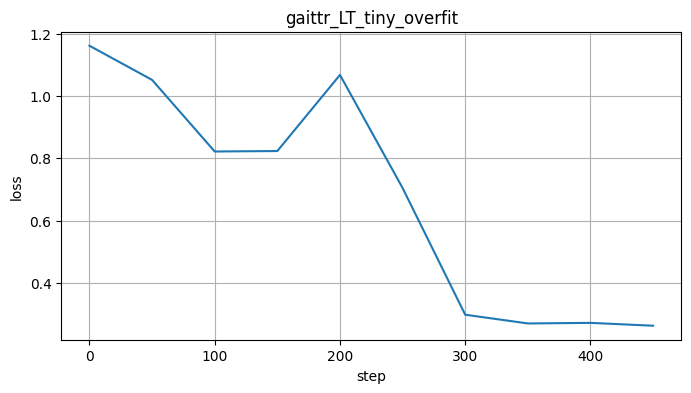

Saved checkpoint: /media/wadud/DriveUbuntu/GaitRecognition 2.0/checkpoints/gaittr_LT_tiny_overfit_last.pth
Saved log: /media/wadud/DriveUbuntu/GaitRecognition 2.0/logs/gaittr_LT_tiny_overfit_train_log.csv


In [6]:
if RUN_TINY_OVERFIT_TEST:
    tiny_subs=sorted(df_train_full.subject.astype(str).unique())[:TINY_SUBJECTS]
    df_tiny=df_train_full[df_train_full.subject.astype(str).isin(tiny_subs)].copy()
    print('Tiny subjects:',tiny_subs,'samples:',len(df_tiny))
    tiny_model,tiny_log=run_training(df_tiny,f'gaittr_{SPLIT_NAME}_tiny_overfit',TINY_STEPS,min(P,TINY_SUBJECTS),K,100)
else:
    print('Tiny test disabled')

In [7]:
if RUN_FULL_TRAINING:
    full_model,full_log=run_training(df_train_full,f'gaittr_{SPLIT_NAME}',MAX_STEPS,P,K,STEPS_PER_EPOCH)
else:
    print('RUN_FULL_TRAINING=False. Set it True after tiny overfit test is okay.')

RUN_FULL_TRAINING=False. Set it True after tiny overfit test is okay.


,step,loss,lr,elapsed_sec
0,0,1.161013,0.000010,0.897964
1,50,1.051318,0.000270,3.942985
2,100,0.821556,0.000767,6.861188
3,150,0.823077,0.001000,9.785349
4,200,1.067306,0.000947,12.729712


,step,loss,lr,elapsed_sec
5,250,0.704451,0.000805,15.409973
6,300,0.297794,0.000602,17.911011
7,350,0.269789,0.000380,20.418260
8,400,0.271646,0.000181,22.977467
9,450,0.262488,0.000046,25.524689


First loss: 1.1610130071640017
Last loss : 0.2624876499176025
Min loss  : 0.2624876499176025


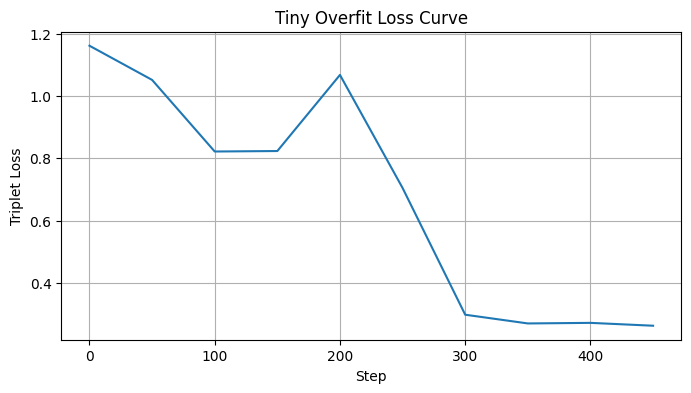

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

EXP_DIR = Path("/media/wadud/DriveUbuntu/GaitRecognition 2.0")
log_path = EXP_DIR / "logs" / "gaittr_LT_tiny_overfit_train_log.csv"

df_log = pd.read_csv(log_path)

display(df_log.head())
display(df_log.tail())

print("First loss:", df_log["loss"].iloc[0])
print("Last loss :", df_log["loss"].iloc[-1])
print("Min loss  :", df_log["loss"].min())

plt.figure(figsize=(8, 4))
plt.plot(df_log["step"], df_log["loss"])
plt.xlabel("Step")
plt.ylabel("Triplet Loss")
plt.title("Tiny Overfit Loss Curve")
plt.grid(True)
plt.show()